##### ***微调技术（Fine-tuning）***
###### 模型经过预训练后已经学会了大量的通用知识，就是是阅读了所有的百科全书，但是它的能力并不尽如人意，可能我需要它在某方面表现的更为优异或者针对专门的任务。而如果选择重新训练一个专业模型，那么所需要的成本巨大，所以为了解决这一问题，微调技术应运而生，简而言之，模型的能力由其中的权重参数决定，所以如果想改变其能力特性，我们只需要修改参数，使其能表达出我们想要的能力特性，所以微调技术通过更小更明确的数据集调整已有预训练模型参数的技术。
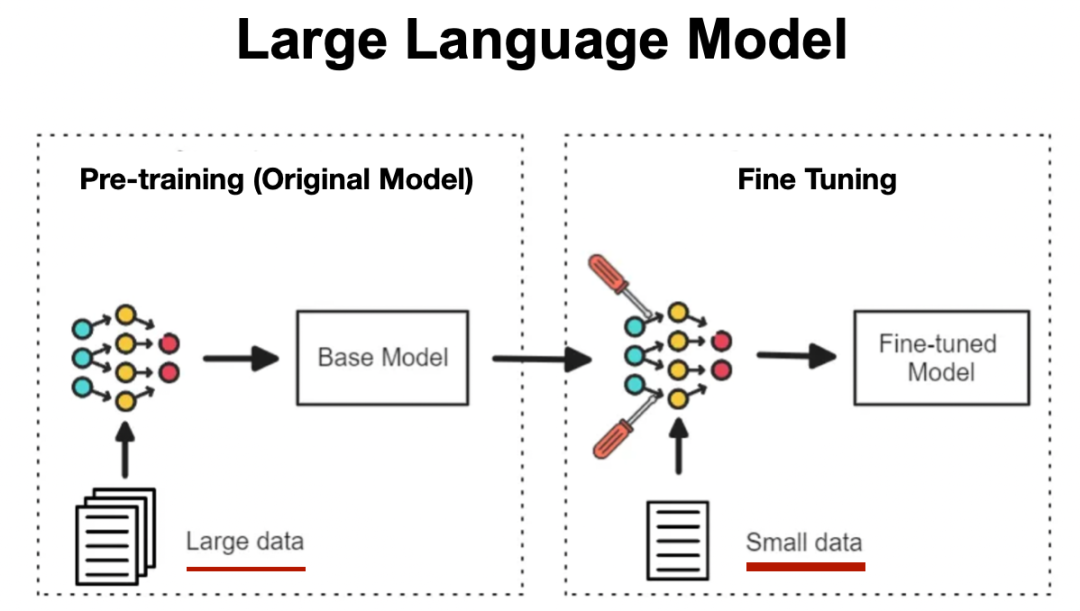
##### ***目前几条主流的Fine-tuning路线***
###### 线代LLM的微调大概可以分为以下几条主流路线：
1. Full Fine-tuning
2. Parameter-Efficient Fine-tuning(PEFT)
3. Supervised Fine-tuning(SFT)
4. Preference Alignment
##### ***1.全参数微调（Full Fine-tuning）***
###### 顾名思义，该技术通过将Pretraining模型的全部参数重新调整来达到我们想要的效果。也就是说，在完成预训练之后，我们并不会冻结模型主体，而是让整个模型继续在下游任务数据上训练，从而使其逐渐适应该任务的目标。由于这种方法会更新模型中的所有参数，因此它在形式上看起来很像“重新训练”了一遍模型，但两者仍然存在本质区别：重新训练通常意味着从随机初始化开始，而Full Fine-tuning则是在预训练权重的基础上继续优化，因此模型并不是从零学习，而是在已有通用语言能力的前提下进一步调整。
###### 这种方法的优点在于简单直接，因为它不需要额外设计新的微调结构，也不需要额外考虑哪些参数应该冻结、哪些参数应该训练，只需要将下游任务的数据送入模型，然后按照目标函数继续训练即可。对于数据量充足且资源允许的情况，全参数微调往往能够取得不错的效果。
###### 但它的问题也十分明显。由于模型中的所有参数都会参与梯度更新，因此显存占用和计算成本都非常高，尤其在大语言模型规模不断增大的背景下，这种方法的代价会迅速变得难以接受。此外，如果不同任务都采用全参数微调，那么每个任务都需要单独保存一整份模型权重，存储成本也会很高。也正因为如此，后续才逐渐发展出了参数高效微调方法。
##### ***2.高效参数微调（PEFT）***
###### 为了解决全参数微调开销过大的问题，研究者提出了高效参数微调，也就是PEFT，Parameter-Efficient Fine-Tuning。它的核心思想并不是去更新整个预训练模型，而是只训练其中很小一部分参数，或者在原模型之上额外添加少量可训练模块，从而用更低的显存、算力和存储成本实现对模型能力的适配。
###### 从直觉上来说，PEFT建立在这样一个认识之上：预训练模型本身已经拥有较强的通用能力，因此在面对具体任务时，往往没有必要重新调整全部参数，只需要对某些关键方向进行小幅修正，就足以让模型在新任务上表现得更好。也就是说，PEFT并不是“重新塑造整个模型”，而更像是在一个已经训练良好的大模型上加上少量“任务适配器”。
###### 在现代大模型实践中，PEFT已经成为非常重要的一条路线，因为它既保留了预训练模型原本的大部分能力，又显著降低了微调门槛。其中最典型、也最常见的方法便是LoRA以及在其基础上进一步发展的QLoRA。它们会在后续笔记中单独展开，因为这也是当前最实用、最值得掌握的微调技术之一。
##### ***3.监督微调（SFT）***
###### 如果说全参数微调和PEFT更多是在讨论“参数应该怎么更新”，那么监督微调SFT，Supervised Fine-Tuning，讨论的则是“模型应该被训练成什么样”。具体来说，SFT通常会使用带有明确输入输出对应关系的数据来继续训练模型，例如指令-回答对、问题-答案对、对话样本或者任务格式化后的监督数据。通过这些数据，模型会逐渐学会按照特定要求去输出结果，而不再只是单纯地根据前文自由续写。
###### 对于现代大语言模型来说，SFT的重要意义在于它往往是从base model走向instruct model的关键一步。一个只经过预训练的模型，虽然具备了强大的语言建模能力，但并不一定擅长遵循用户指令，也不一定能稳定输出我们想要的格式。而经过SFT之后，模型会逐渐学会如何围绕任务目标、按照人类期望的方式给出回答，因此它会变得更像一个“助手”。
###### 值得注意的是，SFT并不一定意味着训练目标发生了根本变化。对于GPT类模型来说，很多时候它在形式上仍然是在做next-token prediction，只不过训练数据已经从普通语料变成了带有明确任务结构的监督数据。也正因为如此，SFT既可以被看作是一种特殊形式的Fine-tuning，也可以被看作是现代助手模型训练流程中的关键阶段。
##### ***4.偏好对齐***
###### 即使模型已经经过了SFT，它也不一定完全符合人类的偏好与要求。比如模型虽然学会了回答问题，但它的回答可能不够有帮助、不够安全，也可能在风格上不稳定，甚至在面对敏感问题时表现得过于服从或者过于保守。因此，仅仅依靠监督微调往往还不足以让模型真正成为一个稳定、可控、符合人类预期的助手，这时便需要进一步引入偏好对齐。
###### 所谓偏好对齐，本质上是让模型不仅学会“如何回答”，还要进一步学会“什么样的回答更符合人类偏好”。这里的人类偏好可能包括：更有帮助、更真实、更安全、更符合伦理边界，或者更符合某种产品风格。与普通任务微调相比，偏好对齐更关注模型行为层面的控制，而不仅仅是任务指标本身。
###### 在现代大语言模型中，偏好对齐最典型的两条路线便是DPO和RLHF。前者是一种更加直接、实现相对简洁的偏好优化方法，后者则是更经典的基于人类反馈进行强化学习优化的路线。无论采用哪种方法，它们的共同目标都是让模型在已有语言能力和指令跟随能力的基础上，进一步朝着人类偏好的方向靠近。因此，从整体流程来看，偏好对齐通常发生在SFT之后，也是现代LLM从“会说话”到“说得更像人想要它说的话”的关键一步。
